In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action='ignore', category=(SettingWithCopyWarning))
warnings.filterwarnings('ignore')

colormap = sns.color_palette("Blues")
sns.set_context("poster")
sns.set_palette("colorblind")
matplotlib.rcParams.update({'font.size': 22})
sns.set(font_scale=2.4)

In [2]:
AGENTS = [
    "meta-llama/Llama-3.1-8B-Instruct",
    "google/gemma-3-4b-it",
    "mistralai/Ministral-3-8B-Instruct-2512",
    "Qwen/Qwen3.5-9B"
]

AGENTS_CLEAN_NAMES = ["Llama-3.1-8B", "Gemma-3-4B", "Ministral-3-8B", "Qwen3.5-9B"]
rename_dict = dict(zip(AGENTS, AGENTS_CLEAN_NAMES))

LOGS_ROOT = "../../../.logs/"

os.makedirs("../figures", exist_ok=True)

#### Utils

In [3]:
def load_games_from_dir(log_dir):
    records = []
    for root, dirs, files in os.walk(log_dir):
        if "game_state.json" not in files:
            continue
        path = os.path.join(root, "game_state.json")
        try:
            with open(path) as f:
                data = json.load(f)
            last = data["game_state"][-1]
            if last.get("current_iteration") != "END":
                continue
            summary = last["summary"]
            players = data["players"]
            records.append({
                "path": path,
                "game_class": data["class"],
                "model_1": players[0].get("model_id", players[0].get("model")),
                "model_2": players[1].get("model_id", players[1].get("model")),
                "summary": summary,
            })
        except Exception as e:
            print(f"Skipping {path}: {e}")
    print(f"Found {len(records)} completed games in {log_dir}")
    return records


def resource_value(res):
    return sum(res["_value"].values())


def replace_names(df):
    df = df.copy()
    df["model_1"] = df["model_1"].replace(rename_dict)
    df["model_2"] = df["model_2"].replace(rename_dict)
    return df

## Game Completion Rates

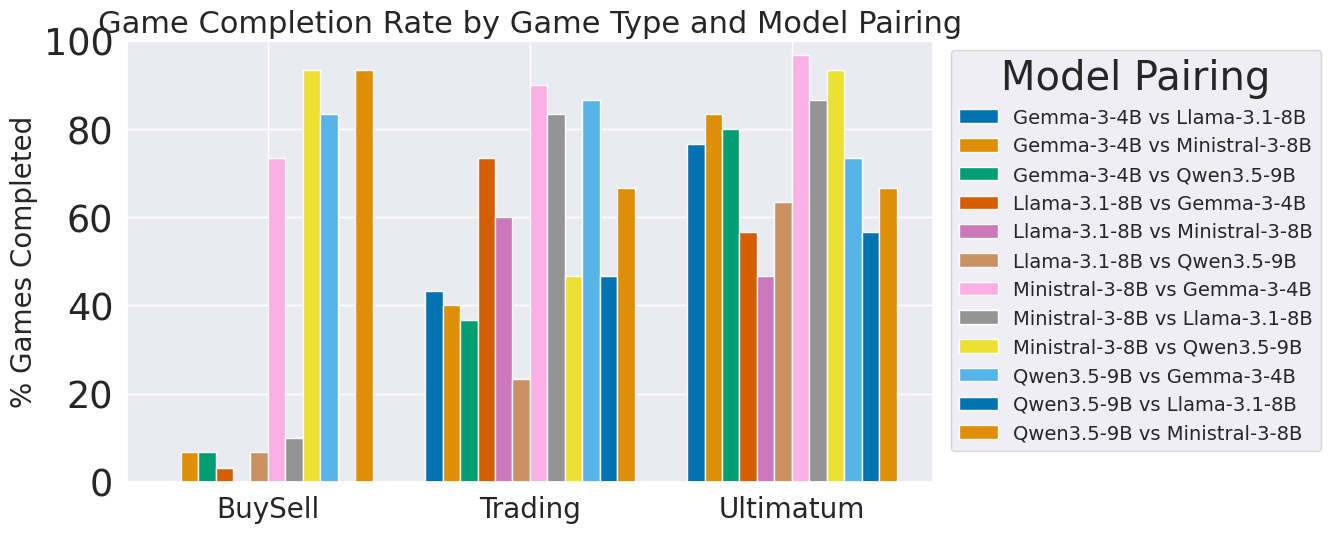

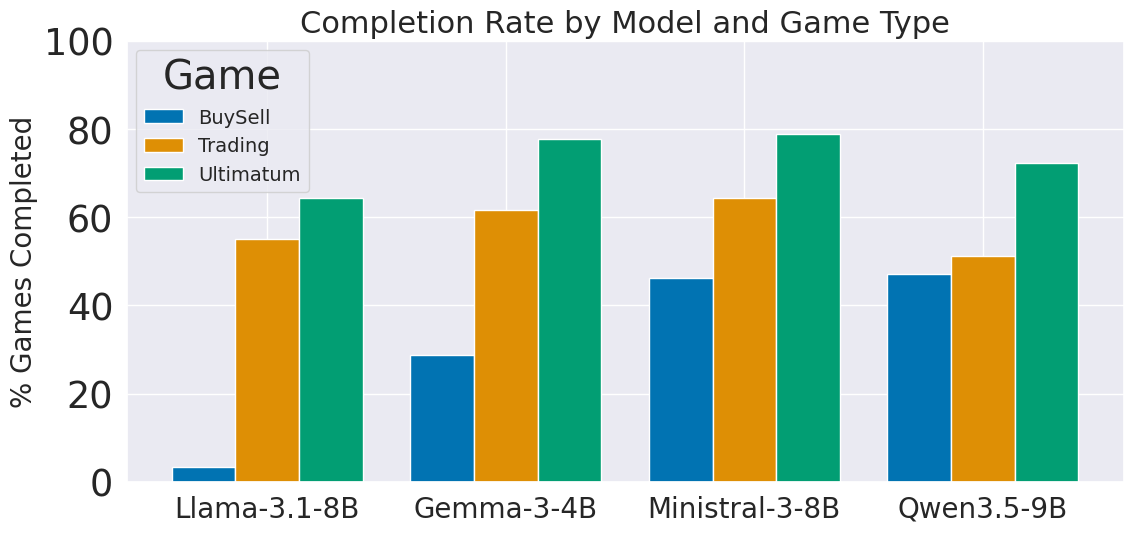

In [4]:
def load_completion_stats(log_dirs):
    """Count total vs completed games per model pairing for each game type."""
    rows = []
    for game_name, log_dir in log_dirs.items():
        for root, dirs, files in os.walk(log_dir):
            if "game_state.json" not in files:
                continue
            path = os.path.join(root, "game_state.json")
            try:
                with open(path) as f:
                    data = json.load(f)
                players = data["players"]
                last = data["game_state"][-1]
                completed = last.get("current_iteration") == "END"
                rows.append({
                    "game": game_name,
                    "model_1": players[0].get("model_id", players[0].get("model", "unknown")),
                    "model_2": players[1].get("model_id", players[1].get("model", "unknown")),
                    "completed": completed,
                })
            except Exception:
                pass
    return pd.DataFrame(rows)


log_dirs = {
    "Trading": os.path.join(LOGS_ROOT, "section_one/trading_section_one"),
    "Ultimatum": os.path.join(LOGS_ROOT, "section_one/ultimatum_section_one"),
    "BuySell": os.path.join(LOGS_ROOT, "section_one/buysell_section_one"),
}

df_raw = load_completion_stats(log_dirs)
df_raw["model_1"] = df_raw["model_1"].replace(rename_dict)
df_raw["model_2"] = df_raw["model_2"].replace(rename_dict)
df_raw["pairing"] = df_raw["model_1"] + " vs " + df_raw["model_2"]

agg = df_raw.groupby(["game", "pairing"]).agg(
    total=("completed", "count"),
    completed=("completed", "sum"),
).reset_index()
agg["pct"] = agg["completed"] / agg["total"] * 100

games = agg["game"].unique()
pairings = sorted(agg["pairing"].unique())
x = np.arange(len(games))
width = 0.8 / len(pairings)

fig, ax = plt.subplots(figsize=(14, 6))
colors = sns.color_palette("colorblind", len(pairings))

for i, pairing in enumerate(pairings):
    sub = agg[agg["pairing"] == pairing].set_index("game")
    vals = [sub.loc[g, "pct"] if g in sub.index else 0 for g in games]
    bars = ax.bar(x + i * width, vals, width, label=pairing, color=colors[i])
    #for bar, val in zip(bars, vals):
        #ax.text(
        #    bar.get_x() + bar.get_width() / 2,
        #    val - 7,
        #    f"{val:.0f}%",
        #    ha="center", va="top", fontsize=12, color="white", fontweight="bold",
        #)

ax.set_xticks(x + width * (len(pairings) - 1) / 2)
ax.set_xticklabels(games, fontsize=20)
ax.set_ylabel("% Games Completed", fontsize=20)
ax.set_title("Game Completion Rate by Game Type and Model Pairing", fontsize=22)
ax.set_ylim(0, 100)
ax.legend(title="Model Pairing", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=14)
fig.tight_layout()
#plt.savefig("../../figures/medium_completion_rate.pdf", bbox_inches="tight")
plt.show()

#  Per-model completion rate 
df_m1 = df_raw[["game", "model_1", "completed"]].rename(columns={"model_1": "model"})
df_m2 = df_raw[["game", "model_2", "completed"]].rename(columns={"model_2": "model"})
agg_model = (
    pd.concat([df_m1, df_m2])
    .groupby(["game", "model"])
    .agg(total=("completed", "count"), completed=("completed", "sum"))
    .reset_index()
)
agg_model["pct"] = agg_model["completed"] / agg_model["total"] * 100

games_list = sorted(agg_model["game"].unique())
models_list = AGENTS_CLEAN_NAMES
x2 = np.arange(len(models_list))
width2 = 0.8 / len(games_list)

fig2, ax2 = plt.subplots(figsize=(12, 6))
game_colors = sns.color_palette("colorblind", len(games_list))

for i, game in enumerate(games_list):
    sub = agg_model[agg_model["game"] == game].set_index("model")
    vals = [sub.loc[m, "pct"] if m in sub.index else 0 for m in models_list]
    ax2.bar(x2 + i * width2, vals, width2, label=game, color=game_colors[i])

ax2.set_xticks(x2 + width2 * (len(games_list) - 1) / 2)
ax2.set_xticklabels(models_list, fontsize=20)
ax2.set_ylabel("% Games Completed", fontsize=20)
ax2.set_title("Completion Rate by Model and Game Type", fontsize=22)
ax2.set_ylim(0, 100)
ax2.legend(title="Game", fontsize=14)
fig2.tight_layout()
#plt.savefig("../../figures/medium_completion_rate_by_model.pdf", bbox_inches="tight")
plt.show()



## Trading

In [5]:
records = load_games_from_dir(os.path.join(LOGS_ROOT, "section_one/trading_section_one"))

rows = []
for r in records:
    s = r["summary"]
    init = s["initial_resources"]
    final = s["final_resources"]
    delta_1 = resource_value(final[0]) - resource_value(init[0])
    delta_2 = resource_value(final[1]) - resource_value(init[1])
    rows.append({
        "game_name": r["game_class"],
        "model_1": r["model_1"],
        "model_2": r["model_2"],
        "resource_delta_1": delta_1,
        "resource_delta_2": delta_2,
    })

trading_df = replace_names(pd.DataFrame(rows))
trading_df.head()

Found 209 completed games in ../../../.logs/section_one/trading_section_one


,game_name,model_1,model_2,resource_delta_1,resource_delta_2
0,TradingGame,Ministral-3-8B,Qwen3.5-9B,-1,1
1,TradingGame,Ministral-3-8B,Qwen3.5-9B,-2,2
2,TradingGame,Ministral-3-8B,Qwen3.5-9B,2,-2
3,TradingGame,Ministral-3-8B,Qwen3.5-9B,-5,5
4,TradingGame,Ministral-3-8B,Qwen3.5-9B,0,0


In [6]:
print("Total trading games:", len(trading_df))
print("Games per pairing:")
print(trading_df.groupby(["model_1", "model_2"]).size().to_string())

Total trading games: 209
Games per pairing:
model_1         model_2       
Gemma-3-4B      Llama-3.1-8B      13
                Ministral-3-8B    12
                Qwen3.5-9B        11
Llama-3.1-8B    Gemma-3-4B        22
                Ministral-3-8B    18
                Qwen3.5-9B         7
Ministral-3-8B  Gemma-3-4B        27
                Llama-3.1-8B      25
                Qwen3.5-9B        14
Qwen3.5-9B      Gemma-3-4B        26
                Llama-3.1-8B      14
                Ministral-3-8B    20


In [7]:
def trading_aggregation(df):
    df = df.copy()
    df["models"] = df["model_1"] + "@" + df["model_2"]
    df["win_1"] = df["resource_delta_1"] > df["resource_delta_2"]
    df["win_2"] = df["resource_delta_1"] < df["resource_delta_2"]

    agg = df.groupby(["game_name", "models"])[
        ["win_1", "win_2", "resource_delta_1", "resource_delta_2"]
    ].mean().reset_index()

    agg[["model_1", "model_2"]] = agg["models"].str.split("@", n=1, expand=True)
    total_decisive = agg["win_1"] + agg["win_2"]
    agg["win_1"] = agg["win_1"] / total_decisive
    agg["win_2"] = agg["win_2"] / total_decisive
    return agg


aggregated = trading_aggregation(trading_df)
aggregated

,game_name,models,win_1,win_2,resource_delta_1,resource_delta_2,model_1,model_2
0,TradingGame,Gemma-3-4B@Llama-3.1-8B,0.250000,0.750000,-4.230769,4.230769,Gemma-3-4B,Llama-3.1-8B
1,TradingGame,Gemma-3-4B@Ministral-3-8B,0.222222,0.777778,-4.333333,4.333333,Gemma-3-4B,Ministral-3-8B
2,TradingGame,Gemma-3-4B@Qwen3.5-9B,0.000000,1.000000,-8.454545,8.454545,Gemma-3-4B,Qwen3.5-9B
3,TradingGame,Llama-3.1-8B@Gemma-3-4B,0.705882,0.294118,2.863636,-2.863636,Llama-3.1-8B,Gemma-3-4B
4,TradingGame,Llama-3.1-8B@Ministral-3-8B,0.312500,0.687500,-3.611111,3.611111,Llama-3.1-8B,Ministral-3-8B
5,TradingGame,Llama-3.1-8B@Qwen3.5-9B,0.166667,0.833333,-3.285714,3.285714,Llama-3.1-8B,Qwen3.5-9B
6,TradingGame,Ministral-3-8B@Gemma-3-4B,0.571429,0.428571,0.814815,-0.814815,Ministral-3-8B,Gemma-3-4B
7,TradingGame,Ministral-3-8B@Llama-3.1-8B,0.250000,0.750000,-3.880000,3.880000,Ministral-3-8B,Llama-3.1-8B
8,TradingGame,Ministral-3-8B@Qwen3.5-9B,0.166667,0.833333,-2.500000,2.500000,Ministral-3-8B,Qwen3.5-9B
9,TradingGame,Qwen3.5-9B@Gemma-3-4B,0.166667,0.833333,-2.807692,2.807692,Qwen3.5-9B,Gemma-3-4B


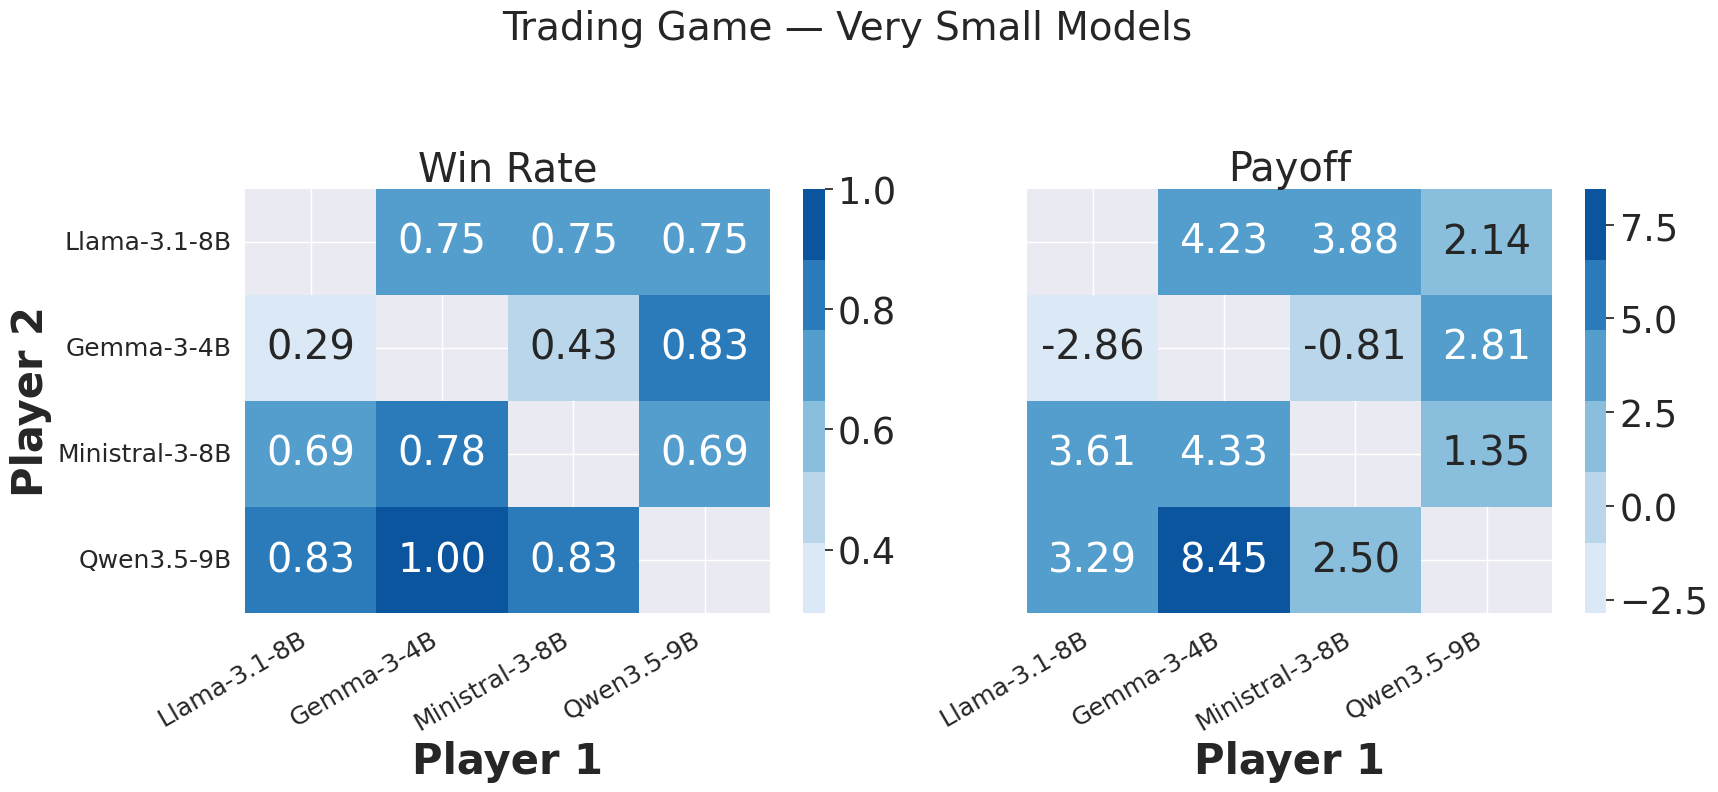

In [8]:
fig, axs = plt.subplots(figsize=(17.6, 8), ncols=2)
fig.tight_layout()

# Win Rate heatmap
local = aggregated.pivot(index="model_2", columns="model_1", values="win_2")
local = local.reindex(AGENTS_CLEAN_NAMES, axis=1).reindex(AGENTS_CLEAN_NAMES)

p1 = sns.heatmap(local, annot=True, fmt=".2f", cmap=colormap, ax=axs[0])
p1.set_ylabel("Player 2", fontdict=dict(weight="bold", size=30))
p1.set_xlabel("Player 1", fontdict=dict(weight="bold", size=30))
p1.set_title("Win Rate")
p1.set_xticklabels(AGENTS_CLEAN_NAMES, rotation=30, ha="right", fontsize=18)
p1.set_yticklabels(AGENTS_CLEAN_NAMES, rotation=0, va="center", fontsize=18)

# Payoff heatmap
local = aggregated.pivot(index="model_2", columns="model_1", values="resource_delta_2")
local = local.reindex(AGENTS_CLEAN_NAMES, axis=1).reindex(AGENTS_CLEAN_NAMES)

p2 = sns.heatmap(local, annot=True, fmt=".2f", cmap=colormap, ax=axs[1])
p2.set_ylabel("")
p2.set_xlabel("Player 1", fontdict=dict(weight="bold", size=30))
p2.set_title("Payoff")
p2.set_xticklabels(AGENTS_CLEAN_NAMES, rotation=30, ha="right", fontsize=18)
p2.set_yticklabels([], fontsize=18)

fig.suptitle("Trading Game — Very Small Models", fontsize=28, y=1.02)
fig.tight_layout()
#plt.savefig("../../figures/medium_trading.pdf", bbox_inches="tight")
plt.show()

## Ultimatum

In [9]:
records = load_games_from_dir(os.path.join(LOGS_ROOT, "section_one/ultimatum_section_one"))

rows = []
for r in records:
    s = r["summary"]
    init = s["initial_resources"]
    final = s["final_resources"]
    delta_1 = resource_value(final[0]) - resource_value(init[0])
    delta_2 = resource_value(final[1]) - resource_value(init[1])
    rows.append({
        "game_name": r["game_class"],
        "model_1": r["model_1"],
        "model_2": r["model_2"],
        "resource_delta_1": delta_1,
        "resource_delta_2": delta_2,
    })

ultimatum_df = replace_names(pd.DataFrame(rows))

ultimatum_df["resource_delta_1"] = ultimatum_df["resource_delta_1"] + 100
ultimatum_df.loc[ultimatum_df["resource_delta_1"] == 100, "resource_delta_1"] = 0

ultimatum_df.head()

Found 264 completed games in ../../../.logs/section_one/ultimatum_section_one


,game_name,model_1,model_2,resource_delta_1,resource_delta_2
0,MultiTurnUltimatumGame,Ministral-3-8B,Qwen3.5-9B,60,40
1,MultiTurnUltimatumGame,Ministral-3-8B,Qwen3.5-9B,10,90
2,MultiTurnUltimatumGame,Ministral-3-8B,Qwen3.5-9B,50,50
3,MultiTurnUltimatumGame,Ministral-3-8B,Qwen3.5-9B,50,50
4,MultiTurnUltimatumGame,Ministral-3-8B,Qwen3.5-9B,50,50


In [10]:
print("Total ultimatum games:", len(ultimatum_df))
print("\nGames per pairing:")
print(ultimatum_df.groupby(["model_1", "model_2"]).size().to_string())
print("\nNo-deal rate per pairing:")
no_deal = ultimatum_df.copy()
no_deal["no_deal"] = (no_deal["resource_delta_1"] == 0) & (no_deal["resource_delta_2"] == 0)
print(no_deal.groupby(["model_1", "model_2"])["no_deal"].mean().to_string())

Total ultimatum games: 264

Games per pairing:
model_1         model_2       
Gemma-3-4B      Llama-3.1-8B      23
                Ministral-3-8B    25
                Qwen3.5-9B        24
Llama-3.1-8B    Gemma-3-4B        17
                Ministral-3-8B    14
                Qwen3.5-9B        19
Ministral-3-8B  Gemma-3-4B        29
                Llama-3.1-8B      26
                Qwen3.5-9B        28
Qwen3.5-9B      Gemma-3-4B        22
                Llama-3.1-8B      17
                Ministral-3-8B    20

No-deal rate per pairing:
model_1         model_2       
Gemma-3-4B      Llama-3.1-8B      0.391304
                Ministral-3-8B    0.120000
                Qwen3.5-9B        0.000000
Llama-3.1-8B    Gemma-3-4B        0.294118
                Ministral-3-8B    0.142857
                Qwen3.5-9B        0.105263
Ministral-3-8B  Gemma-3-4B        0.275862
                Llama-3.1-8B      0.230769
                Qwen3.5-9B        0.107143
Qwen3.5-9B      Gemma-3-4B       

In [11]:
def ultimatum_aggregation(df):
    df = df.copy()
    df["models"] = df["model_1"] + "@" + df["model_2"]
    df["win_1"] = df["resource_delta_1"] > df["resource_delta_2"]
    df["win_2"] = df["resource_delta_1"] < df["resource_delta_2"]

    agg = df.groupby(["game_name", "models"])[
        ["win_1", "win_2", "resource_delta_1", "resource_delta_2"]
    ].mean().reset_index()

    agg[["model_1", "model_2"]] = agg["models"].str.split("@", n=1, expand=True)
    total_decisive = agg["win_1"] + agg["win_2"]
    agg["win_1"] = agg["win_1"] / total_decisive
    agg["win_2"] = agg["win_2"] / total_decisive
    return agg


aggregated = ultimatum_aggregation(ultimatum_df)
aggregated

,game_name,models,win_1,win_2,resource_delta_1,resource_delta_2,model_1,model_2
0,MultiTurnUltimatumGame,Gemma-3-4B@Llama-3.1-8B,1.000000,0.000000,54.173913,6.695652,Gemma-3-4B,Llama-3.1-8B
1,MultiTurnUltimatumGame,Gemma-3-4B@Ministral-3-8B,0.789474,0.210526,64.600000,23.400000,Gemma-3-4B,Ministral-3-8B
2,MultiTurnUltimatumGame,Gemma-3-4B@Qwen3.5-9B,0.913043,0.086957,82.500000,17.500000,Gemma-3-4B,Qwen3.5-9B
3,MultiTurnUltimatumGame,Llama-3.1-8B@Gemma-3-4B,1.000000,0.000000,57.647059,12.941176,Llama-3.1-8B,Gemma-3-4B
4,MultiTurnUltimatumGame,Llama-3.1-8B@Ministral-3-8B,1.000000,0.000000,68.214286,17.500000,Llama-3.1-8B,Ministral-3-8B
5,MultiTurnUltimatumGame,Llama-3.1-8B@Qwen3.5-9B,1.000000,0.000000,68.947368,20.526316,Llama-3.1-8B,Qwen3.5-9B
6,MultiTurnUltimatumGame,Ministral-3-8B@Gemma-3-4B,0.538462,0.461538,44.413793,28.000000,Ministral-3-8B,Gemma-3-4B
7,MultiTurnUltimatumGame,Ministral-3-8B@Llama-3.1-8B,0.500000,0.500000,38.461538,38.461538,Ministral-3-8B,Llama-3.1-8B
8,MultiTurnUltimatumGame,Ministral-3-8B@Qwen3.5-9B,0.500000,0.500000,44.428571,44.857143,Ministral-3-8B,Qwen3.5-9B
9,MultiTurnUltimatumGame,Qwen3.5-9B@Gemma-3-4B,0.833333,0.166667,31.590909,13.863636,Qwen3.5-9B,Gemma-3-4B


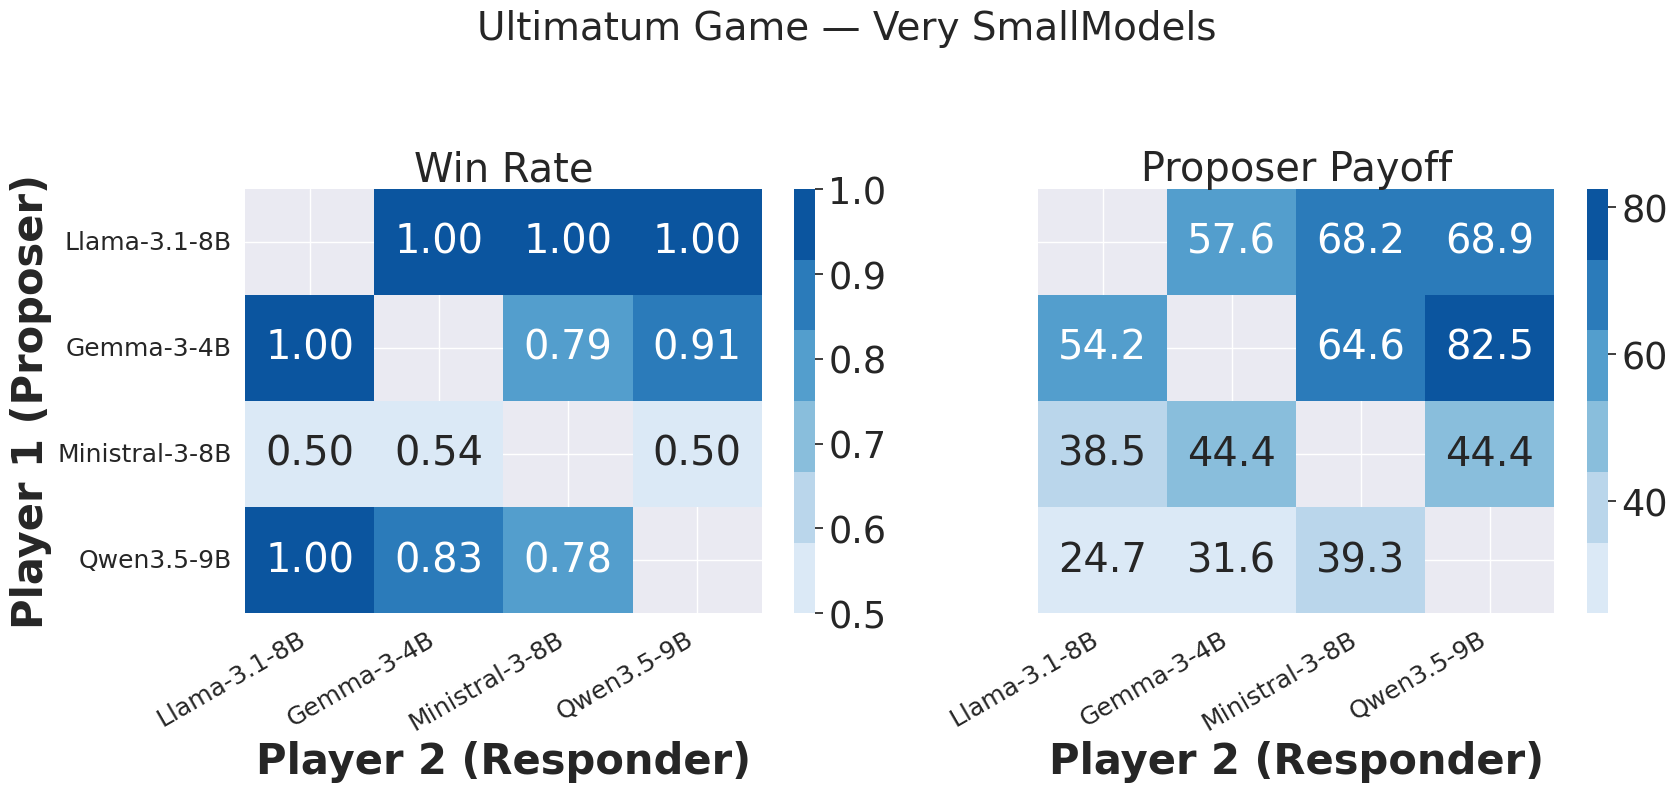

In [12]:
fig, axs = plt.subplots(figsize=(17.6, 8), ncols=2)

# Win Rate heatmap (P1 perspective: P1 is proposer)
local = aggregated.pivot(index="model_1", columns="model_2", values="win_1")
local = local.reindex(AGENTS_CLEAN_NAMES, axis=1).reindex(AGENTS_CLEAN_NAMES)

p1 = sns.heatmap(local, annot=True, fmt=".2f", cmap=colormap, ax=axs[0])
p1.set_title("Win Rate")
p1.set_ylabel("Player 1 (Proposer)", fontdict=dict(weight="bold", size=30))
p1.set_xlabel("Player 2 (Responder)", fontdict=dict(weight="bold", size=30))
p1.set_xticklabels(AGENTS_CLEAN_NAMES, rotation=30, ha="right", fontsize=18)
p1.set_yticklabels(AGENTS_CLEAN_NAMES, rotation=0, va="center", fontsize=18)

# Payoff heatmap
local = aggregated.pivot(index="model_1", columns="model_2", values="resource_delta_1")
local = local.reindex(AGENTS_CLEAN_NAMES, axis=1).reindex(AGENTS_CLEAN_NAMES)

p2 = sns.heatmap(local, annot=True, fmt=".1f", cmap=colormap, ax=axs[1])
p2.set_ylabel("")
p2.set_xlabel("Player 2 (Responder)", fontdict=dict(weight="bold", size=30))
p2.set_title("Proposer Payoff")
p2.set_xticklabels(AGENTS_CLEAN_NAMES, rotation=30, ha="right", fontsize=18)
p2.set_yticklabels([], fontsize=18)

fig.suptitle("Ultimatum Game — Very SmallModels", fontsize=28, y=1.02)
fig.tight_layout()
#plt.savefig("../../figures/medium_ultimatum.pdf", bbox_inches="tight")
plt.show()

## Seller and Buyer

In [13]:
records = load_games_from_dir(os.path.join(LOGS_ROOT, "section_one/buysell_section_one"))

rows = []
for r in records:
    s = r["summary"]
    outcome = s["player_outcome"]
    vals = s["player_valuation"]
    val_1 = vals[0]["_value"]["X"] if vals and vals[0] else None
    val_2 = vals[1]["_value"]["X"] if vals and vals[1] else None
    rows.append({
        "game_name": r["game_class"],
        "model_1": r["model_1"],
        "model_2": r["model_2"],
        "outcome_1": outcome[0],
        "outcome_2": outcome[1],
        "vals1": val_1,
        "vals2": val_2,
    })

buysell_df = replace_names(pd.DataFrame(rows))
buysell_df.head()

Found 113 completed games in ../../../.logs/section_one/buysell_section_one


,game_name,model_1,model_2,outcome_1,outcome_2,vals1,vals2
0,BuySellGame,Ministral-3-8B,Qwen3.5-9B,10,10,40,60
1,BuySellGame,Ministral-3-8B,Qwen3.5-9B,-20,40,40,60
2,BuySellGame,Ministral-3-8B,Qwen3.5-9B,10,10,40,60
3,BuySellGame,Ministral-3-8B,Qwen3.5-9B,5,15,40,60
4,BuySellGame,Ministral-3-8B,Qwen3.5-9B,20,0,40,60


In [14]:
print("Total buy-sell games:", len(buysell_df))
print("\nAvailable seller valuations:", sorted(buysell_df["vals1"].unique()))

gb = buysell_df.groupby("vals1")
groups = {k: v.copy() for k, v in gb}

print("\nGames per valuation x pairing:")
for val, gdf in sorted(groups.items()):
    print(f"  Seller valuation={val}:")
    print(gdf.groupby(["model_1", "model_2"]).size().to_string())

Total buy-sell games: 113

Available seller valuations: [40]

Games per valuation x pairing:
  Seller valuation=40:
model_1         model_2       
Gemma-3-4B      Ministral-3-8B     2
                Qwen3.5-9B         2
Llama-3.1-8B    Gemma-3-4B         1
                Qwen3.5-9B         2
Ministral-3-8B  Gemma-3-4B        22
                Llama-3.1-8B       3
                Qwen3.5-9B        28
Qwen3.5-9B      Gemma-3-4B        25
                Ministral-3-8B    28


Seller at 40 (buyer at 60): 113 games
Filtered 0 outlier games


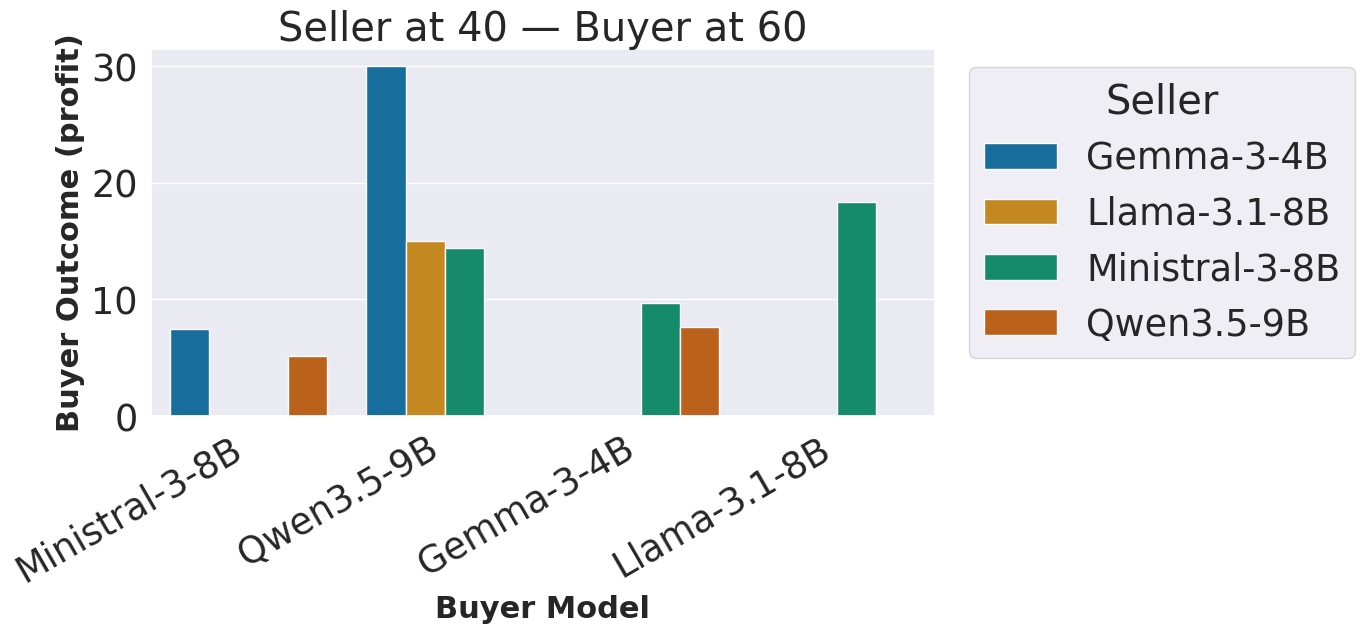

        seller          buyer  outcome_mean  outcome_sem  n
    Gemma-3-4B Ministral-3-8B      7.500000     7.500000  2
    Gemma-3-4B     Qwen3.5-9B     30.000000    10.000000  2
  Llama-3.1-8B     Qwen3.5-9B     15.000000     5.000000  2
Ministral-3-8B     Gemma-3-4B      9.681818     1.823828 22
Ministral-3-8B   Llama-3.1-8B     18.333333     0.881917  3
Ministral-3-8B     Qwen3.5-9B     14.428571     1.933709 28
    Qwen3.5-9B     Gemma-3-4B      7.600000     1.194432 25
    Qwen3.5-9B Ministral-3-8B      5.178571     0.956810 28


In [15]:
seller_at_40 = groups.get(40, pd.DataFrame())
print(f"Seller at 40 (buyer at 60): {len(seller_at_40)} games")

# Filter broken games: buyer profit ∈ [-100, 60]
valid = seller_at_40[
    (seller_at_40["outcome_2"] >= -100) & (seller_at_40["outcome_2"] <= 60)
]
print(f"Filtered {len(seller_at_40) - len(valid)} outlier games")

agg = (
    valid.groupby(["model_1", "model_2"])["outcome_2"]
    .agg(["mean", "sem", "count"])
    .reset_index()
)
agg.columns = ["seller", "buyer", "outcome_mean", "outcome_sem", "n"]
agg = agg[agg["n"] >= 2]

fig, ax = plt.subplots(figsize=(14, 7))
sns.barplot(
    data=agg, x="buyer", y="outcome_mean", hue="seller",
    palette="colorblind", capsize=0.1, ax=ax
)
ax.set_ylabel("Buyer Outcome (profit)", fontdict=dict(weight="bold", size=22))
ax.set_xlabel("Buyer Model", fontdict=dict(weight="bold", size=22))
ax.set_title("Seller at 40 — Buyer at 60")
ax.legend(title="Seller", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")

fig.tight_layout()
fig.savefig("../figures/medium_seller_at_40.pdf", bbox_inches="tight")
plt.show()

print(agg.to_string(index=False))

### Buy-Sell — Outcome Heatmaps

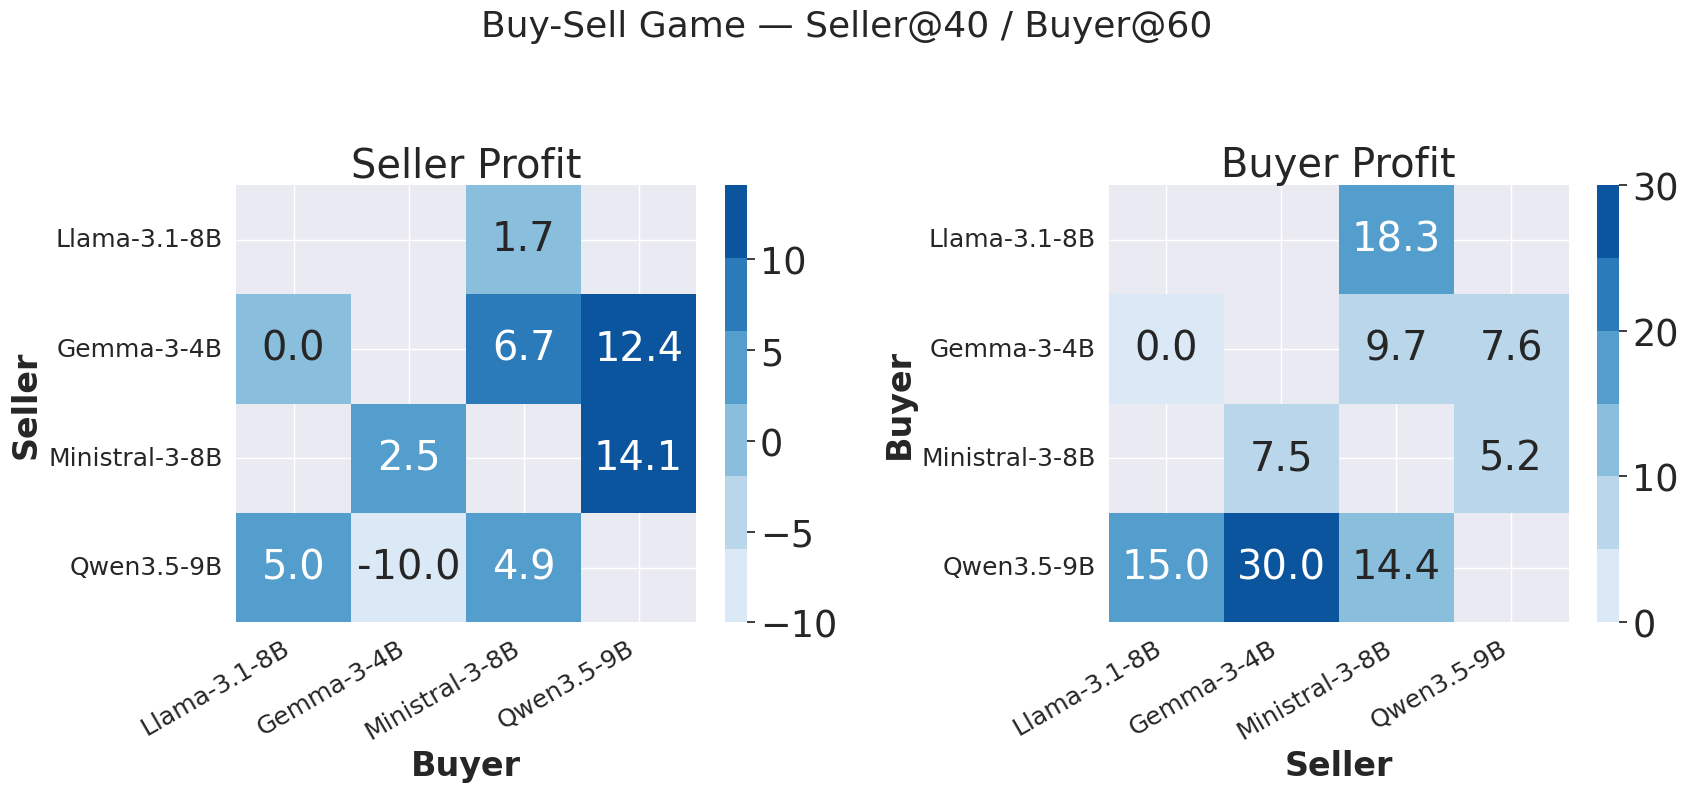

In [16]:
if len(valid) > 0:
    fig, axs = plt.subplots(figsize=(17.6, 8), ncols=2)

    for ax, (col, title) in zip(axs, [("outcome_1", "Seller Profit"), ("outcome_2", "Buyer Profit")]):
        pivot_data = valid.groupby(["model_1", "model_2"])[col].mean().reset_index()
        pivot = pivot_data.pivot(index="model_2", columns="model_1", values=col)
        pivot = pivot.reindex(AGENTS_CLEAN_NAMES, axis=1).reindex(AGENTS_CLEAN_NAMES)

        sns.heatmap(pivot, annot=True, fmt=".1f", cmap=colormap, ax=ax)
        ax.set_title(title)
        ax.set_ylabel("Buyer" if col == "outcome_2" else "Seller",
                      fontdict=dict(weight="bold", size=24))
        ax.set_xlabel("Seller" if col == "outcome_2" else "Buyer",
                      fontdict=dict(weight="bold", size=24))
        ax.set_xticklabels(AGENTS_CLEAN_NAMES, rotation=30, ha="right", fontsize=18)
        ax.set_yticklabels(AGENTS_CLEAN_NAMES, rotation=0, va="center", fontsize=18)

    fig.suptitle("Buy-Sell Game — Seller@40 / Buyer@60", fontsize=26, y=1.02)
    fig.tight_layout()
    #plt.savefig("../../figures/medium_buysell_heatmap.pdf", bbox_inches="tight")
    plt.show()